# 01 — Explore the PhysioNet/CinC Challenge 2012 data

This notebook explores the released Challenge data under the original competition information boundary while preserving the **original competition information boundary**.

- **Set A (4,000):** training set; outcomes were visible to participants.
- **Set B (4,000):** challenge test set; records were visible, outcomes were withheld; participants received scores after submissions.
- **Set C (4,000):** final hidden test set; neither records nor outcomes were available to participants during development.

Today all three sets and outcome files are public. We may use B/C outcomes for **retrospective scoring only**, never for feature design, normalization, hyperparameter tuning, threshold selection, or early stopping.

The raw measurements remain irregularly sampled. The project's hourly representation is a modelling choice, not a property of the source data.


In [5]:
import sys, copy, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from sklearn.model_selection import train_test_split

cwd = Path.cwd().resolve()
if (cwd / "src").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError("Start Jupyter from repository root or notebooks/.")
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.physionet import load_split
from src.data.preprocessing import Physionet2012Dataset, build_vocab

RAW_DIR = PROJECT_ROOT / "data" / "raw"
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
plt.rcParams["figure.dpi"] = 110
print("Project root:", PROJECT_ROOT)


Project root: C:\Users\guido\git_projects\icu-continuous-forecasting


In [6]:
for split in ["set-a","set-b","set-c"]:
    d = RAW_DIR / split
    assert d.is_dir(), f"Missing {d}"
    n = len(list(d.glob("*.txt")))
    assert n == 4000, f"{split}: expected 4000 files, found {n}"
for f in ["Outcomes-a.txt","Outcomes-b.txt","Outcomes-c.txt"]:
    assert (RAW_DIR/f).is_file(), f"Missing {RAW_DIR/f}"
print("OK: A/B/C and all released outcome files are present.")


OK: A/B/C and all released outcome files are present.


## 1. Load the three record sets

For EDA we load Set A and the input side of Set B. **Set C is intentionally not loaded or inspected**, because it was the hidden final test set. B outcomes are not used.


In [7]:
A = load_split(RAW_DIR, split="set-a")
B = load_split(RAW_DIR, split="set-b")

assert len(A) == len(B) == 4000
yA = np.asarray([int(r.label) for r in A if r.label is not None])
assert len(yA) == 4000
assert all(r.label is None for r in B), "Set B must remain unlabeled during EDA."

display(pd.DataFrame([
    {"set":"A","role_2012":"training","n":len(A),"used_in_EDA":"yes","outcomes_used":"yes"},
    {"set":"B","role_2012":"submission test","n":len(B),"used_in_EDA":"input side only","outcomes_used":"no"},
    {"set":"C","role_2012":"final hidden test","n":4000,"used_in_EDA":"no","outcomes_used":"no"},
]))
print(f"Set A in-hospital mortality: {yA.mean():.1%} ({yA.sum()}/{len(yA)})")
print("Set C is intentionally NOT loaded in this notebook.")


,set,role_2012,n,used_in_EDA,outcomes_used
0,A,training,4000,yes,yes
1,B,submission test,4000,input side only,no
2,C,final hidden test,4000,no,no


Set A in-hospital mortality: 13.9% (554/4000)
Set C is intentionally NOT loaded in this notebook.


## 2. Input-distribution diagnostics across A/B

Comparing A and B input distributions is legitimate because B records were visible during the challenge. We do **not** use B outcomes, and C remains unopened.


In [8]:
def input_summary(name, records):
    obs = np.asarray([sum(len(v) for v in r.values.values()) for r in records])
    nvars = np.asarray([sum(len(v) > 0 for v in r.values.values()) for r in records])
    return {"set":name, "patients":len(records),
            "median_raw_observations":np.median(obs),
            "IQR_raw_observations":np.quantile(obs,.75)-np.quantile(obs,.25),
            "median_variables_observed":np.median(nvars)}

display(pd.DataFrame([
    input_summary("A", A),
    input_summary("B", B),
]).round(2))


,set,patients,median_raw_observations,IQR_raw_observations,median_variables_observed
0,A,4000,392.0,138.0,26.0
1,B,4000,391.0,138.0,26.0


In [9]:
vocabs = {"A": set(build_vocab(A)), "B": set(build_vocab(B))}
print("Vocabulary sizes:", {k: len(v) for k, v in vocabs.items()})
print("B variables absent from A:", sorted(vocabs["B"] - vocabs["A"]))


Vocabulary sizes: {'A': 36, 'B': 36}
B variables absent from A: []


## 3. Set-A outcome-aware EDA

Only Set A labels are used for exploratory relationships with mortality, matching the information available to participants.


In [10]:
rows=[]
for r in A:
    rows.append({"record_id":r.record_id,"death":int(r.label),
                 "n_observations":sum(len(v) for v in r.values.values()),
                 "n_variables":sum(len(v)>0 for v in r.values.values())})
edaA=pd.DataFrame(rows)
display(edaA.groupby("death")[["n_observations","n_variables"]].agg(["median","mean"]).round(2))


n_observations         n_variables       
              median    mean      median   mean
death                                          
0              390.0  399.06        26.0  25.46
1              407.0  421.78        28.0  27.53

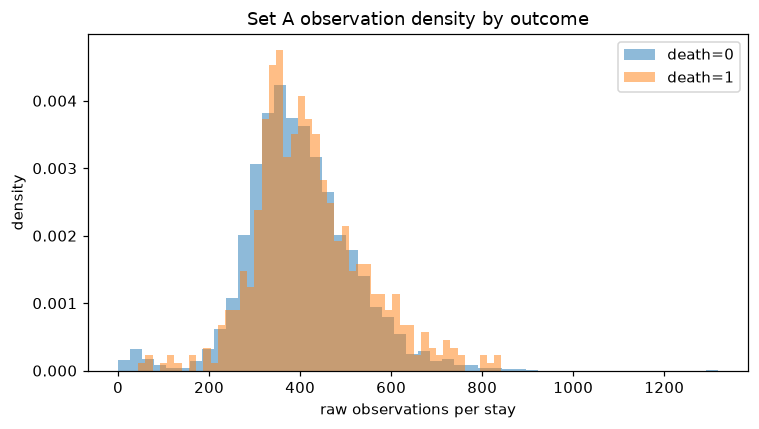

In [11]:
plt.figure(figsize=(7,4))
for death,g in edaA.groupby("death"):
    plt.hist(g["n_observations"], bins=50, alpha=.5, density=True, label=f"death={death}")
plt.xlabel("raw observations per stay"); plt.ylabel("density")
plt.title("Set A observation density by outcome"); plt.legend(); plt.tight_layout(); plt.show()


## 4. Irregular sampling

Pool positive time gaps from a manageable sample of A and B. This demonstrates why continuous-time models are scientifically relevant.


In [12]:
def positive_gaps(records, n=250):
    gaps = []
    for r in records[:n]:
        for pts in r.values.values():
            t = np.asarray([p[0] for p in pts], dtype=float)
            if len(t) > 1:
                d = np.diff(np.sort(t))
                gaps.extend(d[d > 0])
    return np.asarray(gaps)

gap_rows = []
for name, rs in [("A", A), ("B", B)]:
    g = positive_gaps(rs)
    gap_rows.append({
        "set": name,
        "n_gaps": len(g),
        "median_dt_h": np.median(g),
        "p90_dt_h": np.quantile(g, .9),
    })
display(pd.DataFrame(gap_rows).round(3))


,set,n_gaps,median_dt_h,p90_dt_h
0,A,93312,1.0,4.083
1,B,93414,1.0,4.000
